# 02 - Exploratory Data Analysis

Compute RFM metrics from the cleaned data and explore their distributions
before applying scoring or clustering.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())

from src.data.load_data import load_config, load_raw_data
from src.data.preprocess import clean_transactions
from src.features.feature_engineering import compute_rfm

config = load_config("config.yaml")
raw = load_raw_data(config)
clean = clean_transactions(raw)

rfm = compute_rfm(clean, config["rfm"]["reference_date_offset_days"])
print("Number of customers:", rfm.shape[0])
rfm.describe()

Number of customers: 4338


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## Distributions

Recency, Frequency, and Monetary are typically right-skewed -- a small
number of customers purchase very frequently or spend very heavily. This
is exactly why RFM scoring rank-transforms these values before binning
(see `src/features/feature_engineering.py`), rather than binning raw
values directly.

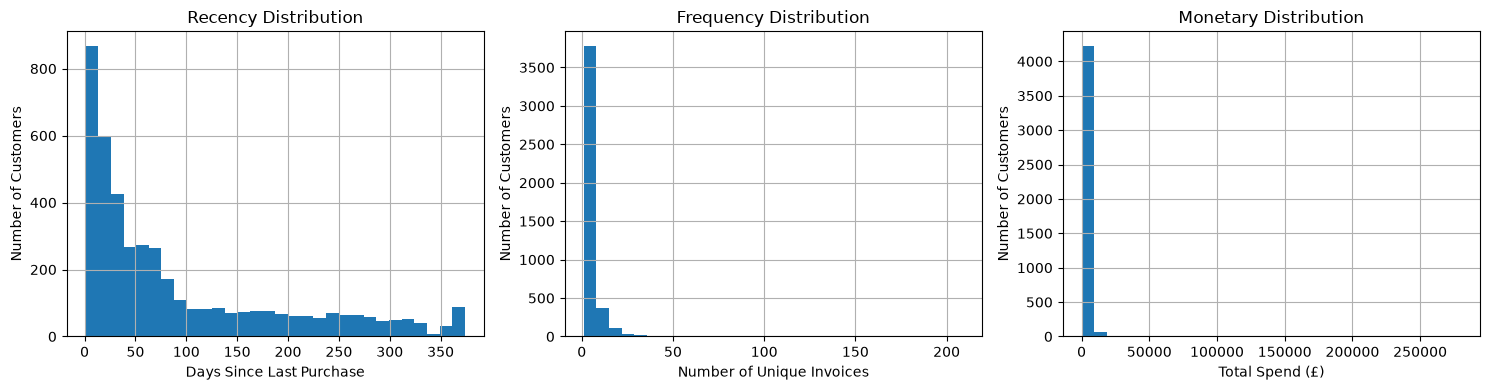

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm["Recency"].hist(bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")
axes[0].set_ylabel("Number of Customers")

rfm["Frequency"].hist(bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Unique Invoices")
axes[1].set_ylabel("Number of Customers")

rfm["Monetary"].hist(bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spend (£)")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [3]:
# Check skewness numerically
print("Recency skew:", rfm["Recency"].skew())
print("Frequency skew:", rfm["Frequency"].skew())
print("Monetary skew:", rfm["Monetary"].skew())

Recency skew: 1.2460475158158468
Frequency skew: 12.067030826322075
Monetary skew: 19.32495323682082
